# Taxi Fare Prediction
This notebook predicts taxi fares using various regression models.

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler

## Load Data

In [2]:
df = pd.read_csv(r"c:\Users\aryan\OneDrive\Desktop\AI ML\ASSIGNMENT\data.csv")
df.head()

C:\Users\aryan\AppData\Local\Temp\ipykernel_27676\217309712.py:1: DtypeWarning: Columns (0: store_and_fwd_flag) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"c:\Users\aryan\OneDrive\Desktop\AI ML\ASSIGNMENT\data.csv")


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
0,1.0,2020-01-01 00:28:15,2020-01-01 00:33:03,1.0,1.2,1.0,N,238,239,1.0,6.0,3.0,0.5,1.47,0.0,0.3,11.27,2.5
1,1.0,2020-01-01 00:35:39,2020-01-01 00:43:04,1.0,1.2,1.0,N,239,238,1.0,7.0,3.0,0.5,1.50,0.0,0.3,12.30,2.5
2,1.0,2020-01-01 00:47:41,2020-01-01 00:53:52,1.0,0.6,1.0,N,238,238,1.0,6.0,3.0,0.5,1.00,0.0,0.3,10.80,2.5
3,1.0,2020-01-01 00:55:23,2020-01-01 01:00:14,1.0,0.8,1.0,N,238,151,1.0,5.5,0.5,0.5,1.36,0.0,0.3,8.16,0.0
4,2.0,2020-01-01 00:01:58,2020-01-01 00:04:16,1.0,0.0,1.0,N,193,193,2.0,3.5,0.5,0.5,0.00,0.0,0.3,4.80,0.0


## Data Exploration

In [3]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 6405008 entries, 0 to 6405007
Data columns (total 18 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   VendorID               float64
 1   tpep_pickup_datetime   str    
 2   tpep_dropoff_datetime  str    
 3   passenger_count        float64
 4   trip_distance          float64
 5   RatecodeID             float64
 6   store_and_fwd_flag     str    
 7   PULocationID           int64  
 8   DOLocationID           int64  
 9   payment_type           float64
 10  fare_amount            float64
 11  extra                  float64
 12  mta_tax                float64
 13  tip_amount             float64
 14  tolls_amount           float64
 15  improvement_surcharge  float64
 16  total_amount           float64
 17  congestion_surcharge   float64
dtypes: float64(13), int64(2), str(3)
memory usage: 879.6 MB
None


In [4]:
print(df.describe())

           VendorID  passenger_count  trip_distance    RatecodeID  \
count  6.339567e+06     6.339567e+06   6.405008e+06  6.339567e+06   
mean   1.669624e+00     1.515333e+00   2.929644e+00  1.059908e+00   
std    4.703484e-01     1.151594e+00   8.315911e+01  8.118432e-01   
min    1.000000e+00     0.000000e+00  -3.062000e+01  1.000000e+00   
25%    1.000000e+00     1.000000e+00   9.600000e-01  1.000000e+00   
50%    2.000000e+00     1.000000e+00   1.600000e+00  1.000000e+00   
75%    2.000000e+00     2.000000e+00   2.930000e+00  1.000000e+00   
max    2.000000e+00     9.000000e+00   2.102401e+05  9.900000e+01   

       PULocationID  DOLocationID  payment_type   fare_amount         extra  \
count  6.405008e+06  6.405008e+06  6.339567e+06  6.405008e+06  6.405008e+06   
mean   1.647323e+02  1.626627e+02  1.270298e+00  1.269411e+01  1.115456e+00   
std    6.554374e+01  6.991261e+01  4.739985e-01  1.212730e+01  1.260054e+00   
min    1.000000e+00  1.000000e+00  1.000000e+00 -1.238000e+03 

In [5]:
print(df.isnull().sum())

VendorID                 65441
tpep_pickup_datetime         0
tpep_dropoff_datetime        0
passenger_count          65441
trip_distance                0
RatecodeID               65441
store_and_fwd_flag       65441
PULocationID                 0
DOLocationID                 0
payment_type             65441
fare_amount                  0
extra                        0
mta_tax                      0
tip_amount                   0
tolls_amount                 0
improvement_surcharge        0
total_amount                 0
congestion_surcharge         0
dtype: int64


## Data Cleaning

In [6]:
df = df.dropna()
print(df.duplicated().sum())
df = df.drop_duplicates()

0


## Feature Engineering

In [7]:
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])

df['year'] = df['tpep_pickup_datetime'].dt.year
df['month'] = df['tpep_pickup_datetime'].dt.month
df['day'] = df['tpep_pickup_datetime'].dt.day
df['hour'] = df['tpep_pickup_datetime'].dt.hour

df['distance'] = df['trip_distance']

## Remove Outliers

In [8]:
Q1 = df['fare_amount'].quantile(0.25)
Q3 = df['fare_amount'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['fare_amount'] >= lower) & (df['fare_amount'] <= upper)]

## Data Visualization

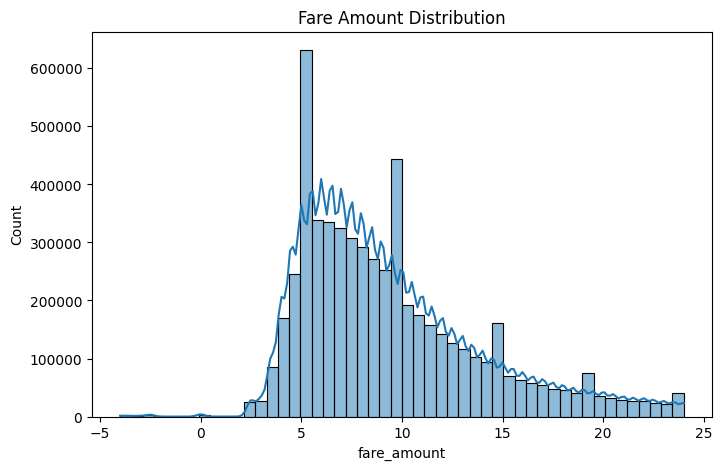

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df['fare_amount'], bins=50, kde=True)
plt.title("Fare Amount Distribution")
plt.show()

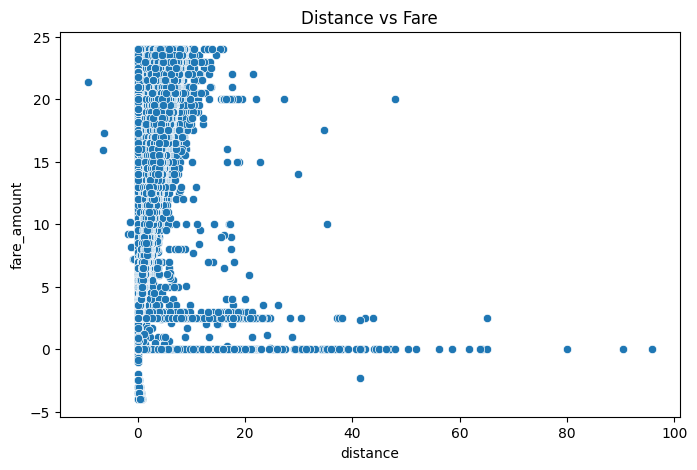

In [10]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['distance'], y=df['fare_amount'])
plt.title("Distance vs Fare")
plt.show()

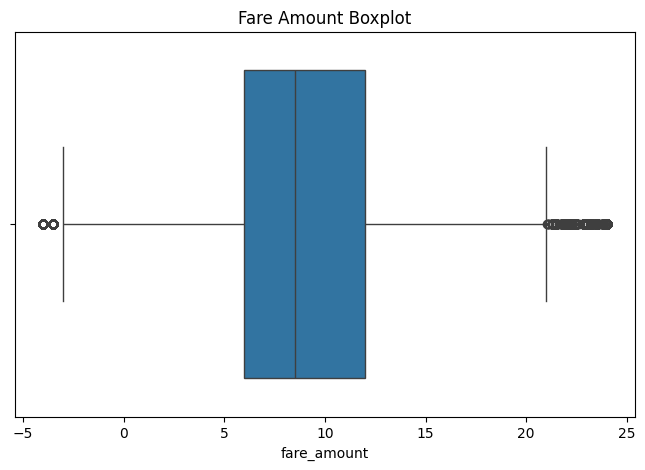

In [11]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['fare_amount'])
plt.title("Fare Amount Boxplot")
plt.show()

## Prepare Features and Target

In [12]:
features = [
    'passenger_count',
    'year',
    'month',
    'day',
    'hour',
    'distance'
]

X = df[features]
y = df['fare_amount']

## Scale Features

In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Train-Test Split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

## Model Training and Evaluation

In [ ]:
lr = LinearRegression()
rf = RandomForestRegressor(n_estimators=100, random_state=42)
gb = GradientBoostingRegressor(random_state=42)

models = {
    "Linear Regression": lr,
    "Random Forest": rf,
    "Gradient Boosting": gb
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    
    results.append([name, mae, rmse, r2])

results_df = pd.DataFrame(
    results,
    columns=["Model", "MAE", "RMSE", "R2 Score"]
)

print(results_df)

## Model Comparison Visualization

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(x="Model", y="R2 Score", data=results_df)
plt.title("Model Comparison")
plt.show()